# Классификация стадий сна — YDL 2026, Неделя 2 (финал)

**Задача.** По 30-секундным эпохам полисомнографии (EEG/EMG/EOG/пульс/дыхание) предсказать стадию сна:
`0=Wake`, `1=Light`, `2=Deep`, `3=REM`.

**Метрика соревнования — macro-F1** (среднее F1 по 4 классам, все классы равноценны). Поэтому всю валидацию ведём по `scoring='f1_macro'`, а не по accuracy.

**Правила/самоограничения.** Только предоставленные данные. Решаем средствами, пройденными в курсе (дни 8–9): `scikit-learn` — LogReg, KNN, SVM, RandomForest, ExtraTrees, HistGradientBoosting, Voting, Stacking. **Без LightGBM/CatBoost.**

**План (с самооценкой после каждой ячейки):**
1. Загрузка → 2. EDA → 3. Препроцессинг + feature engineering → 4. Базовые модели (CV) → 5. Тюнинг гиперпараметров (GridSearch vs RandomizedSearch) → 6. Ансамбли (Voting vs Stacking) → 7. Диагностика → 8. Сабмит → 9. Выводы.

> Принцип курса: *«не верь числу — проверь»*. После каждой ячейки фиксируем, что увидели и что это значит.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Среда готова. Все модели — из scikit-learn (без LightGBM/CatBoost).")

Среда готова. Все модели — из scikit-learn (без LightGBM/CatBoost).


**🔎 Вывод.** Фиксируем `RANDOM_STATE=42` — это обеспечивает воспроизводимость (требование хакатона: код должен давать тот же результат повторно).

## 1. Загрузка данных

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")
print("train:", train.shape, "| test:", test.shape, "| sample_submission:", sample.shape)
print("\nstolbtsy train:", list(train.columns))
print("\nsample_submission (формат сабмита):"); print(sample.head(3).to_string(index=False))
print("\nid train:", train.id.min(), "-", train.id.max(), "| id test:", test.id.min(), "-", test.id.max())

train: (9000, 23) | test: (5000, 22) | sample_submission: (5000, 2)

stolbtsy train: ['id', 'eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate', 'emg_chin_tone', 'emg_tone_variance', 'eog_movement_density', 'eog_amplitude', 'heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index', 'eog_burst_index', 'sleep_stage']

sample_submission (формат сабмита):
  id  sleep_stage
9000            1
9001            1
9002            1

id train: 0 - 8999 | id test: 9000 - 13999


**🔎 Вывод.**
- 9000 обучающих эпох, 5000 тестовых, 21 признак + `id` + `sleep_stage`.
- `id` train (0–8999) и test (9000–13999) **не пересекаются** — утечки по id нет.
- Формат сабмита: две колонки `id,sleep_stage`. На это и ориентируем финальный файл.

## 2. Разведочный анализ (EDA)
Смотрим на данные раньше, чем на модели.

In [3]:
display(train.head())
train.describe().T[["mean","std","min","max"]].round(3)

,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,...,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,...,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,...,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,...,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,...,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,...,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


,mean,std,min,max
id,4499.500,2598.221,0.000,8999.000
eeg_delta_power,-0.015,2.431,-9.567,8.798
eeg_theta_power,-0.034,2.408,-8.277,9.222
eeg_alpha_power,-0.016,5.042,-20.632,18.870
eeg_sigma_power,0.012,2.207,-7.948,9.603
eeg_beta_power,-0.010,2.883,-11.460,10.027
eeg_gamma_power,-0.011,2.428,-9.638,8.296
eeg_slow_osc_power,-0.014,2.801,-14.123,10.362
eeg_spectral_entropy,0.010,2.753,-9.301,10.160
eeg_spindle_density,0.006,2.174,-8.828,8.937


**🔎 Вывод.** Признаки на **разных масштабах** (например, мощности EEG и индексы движений). Из лекции по SVM: *масштабировать признаки нужно всегда* — иначе ось с большими числами перетянет границу. Поэтому для SVM/KNN/LogReg обязателен `StandardScaler`; деревьям масштаб не важен.

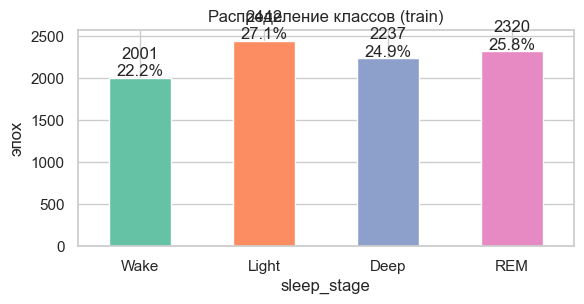

In [4]:
names = {0:"Wake",1:"Light",2:"Deep",3:"REM"}
vc = train.sleep_stage.value_counts().sort_index()
ax = vc.rename(index=names).plot(kind="bar", color=sns.color_palette("Set2"), figsize=(6,3.2))
ax.set_title("Распределение классов (train)"); ax.set_ylabel("эпох"); plt.xticks(rotation=0)
for i,v in enumerate(vc): ax.text(i, v+20, f"{v}\n{v/len(train)*100:.1f}%", ha="center")
plt.tight_layout(); plt.show()

**🔎 Вывод.** Классы **почти сбалансированы** (22–27%). Это важно для выбора метрики и стратегии:
- сильного дисбаланса нет → специальные приёмы (oversampling, `class_weight`) не обязательны;
- но macro-F1 всё равно требует ровной работы по **всем** классам, поэтому валидацию делаем стратифицированной.

In [5]:
feat = [c for c in train.columns if c not in ("id","sleep_stage")]
miss = train[feat].isna().sum(); miss = miss[miss>0]
print("Пропуски в train:\n", miss.to_string())
print("\neog_burst_index пропущен: train %.1f%% | test %.1f%%" %
      (train.eog_burst_index.isna().mean()*100, test.eog_burst_index.isna().mean()*100))
print("\nДоля пропусков eog_burst_index ПО КЛАССАМ:")
print(train.groupby("sleep_stage").eog_burst_index.apply(lambda s: s.isna().mean()).rename(index=names).round(3).to_string())

Пропуски в train:
 eog_burst_index    4501

eog_burst_index пропущен: train 50.0% | test 49.5%

Доля пропусков eog_burst_index ПО КЛАССАМ:
sleep_stage
Wake     0.486
Light    0.496
Deep     0.504
REM      0.512


**🔎 Вывод (ключевая находка).** Пропущен только `eog_burst_index` — ровно ~50% и в train, и в test. Доля пропусков **одинакова во всех классах (48–51%)** → пропуски **MCAR** (случайны относительно стадии сна). Следствия:
- бинарный флаг «значение пропущено» сам по себе **почти не несёт информации о классе** (проверим позже);
- но **само значение** `eog_burst_index`, когда оно есть, информативно (см. ANOVA ниже), поэтому колонку выбрасывать нельзя;
- безопасные стратегии: либо медианная импутация, либо модель с нативной поддержкой `NaN` (`HistGradientBoosting`).

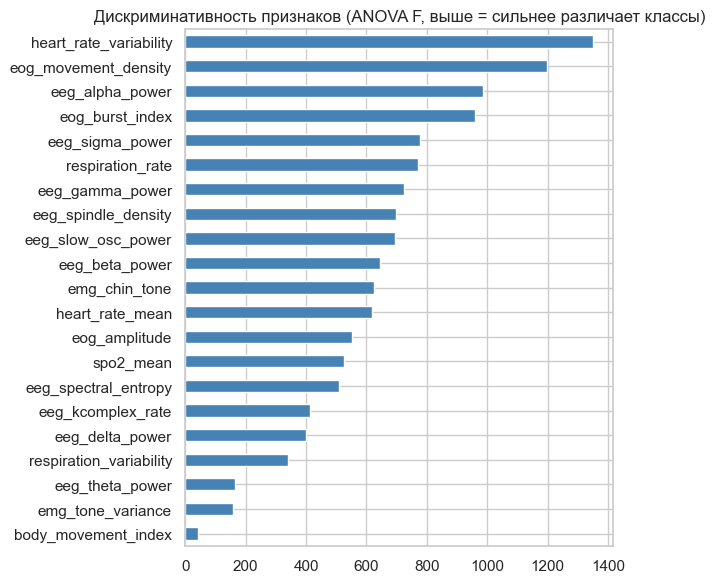

In [6]:
from sklearn.feature_selection import f_classif
Xf = train[feat].fillna(train[feat].median())
F,_ = f_classif(Xf, train.sleep_stage)
imp = pd.Series(F, index=feat).sort_values()
imp.plot(kind="barh", figsize=(6.5,6), color="steelblue")
plt.title("Дискриминативность признаков (ANOVA F, выше = сильнее различает классы)")
plt.tight_layout(); plt.show()

**🔎 Вывод.** Сильнее всего стадии различают `heart_rate_variability`, `eog_movement_density`, `eeg_alpha_power`, `eog_burst_index`, `eeg_sigma_power`. Слабый — `body_movement_index` (F≈40). Вывод: `eog_burst_index` — в топе, его обязательно сохраняем. Удалять слабые признаки не будем — ансамбли деревьев устойчивы к шумовым колонкам.

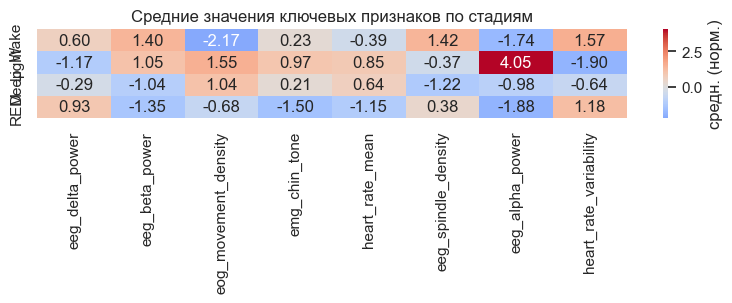

In [7]:
key = ["eeg_delta_power","eeg_beta_power","eog_movement_density","emg_chin_tone",
       "heart_rate_mean","eeg_spindle_density","eeg_alpha_power","heart_rate_variability"]
g = train.groupby("sleep_stage")[key].mean(); g.index = [names[i] for i in g.index]
plt.figure(figsize=(8,3.2))
sns.heatmap(g, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"label":"средн. (норм.)"})
plt.title("Средние значения ключевых признаков по стадиям"); plt.tight_layout(); plt.show()

**🔎 Вывод (физиологичность данных).** Паттерны совпадают с реальной сомнологией → сигнал в данных настоящий, есть что учить:
- **REM**: резко низкий `emg_chin_tone` (мышечная атония — классический признак REM);
- **Wake**: высокий `eeg_beta_power` (бодрствование), отрицательная плотность движений глаз;
- **Deep**: низкие beta и spindle;
- **Light**: высокий пульс и плотность движений глаз.

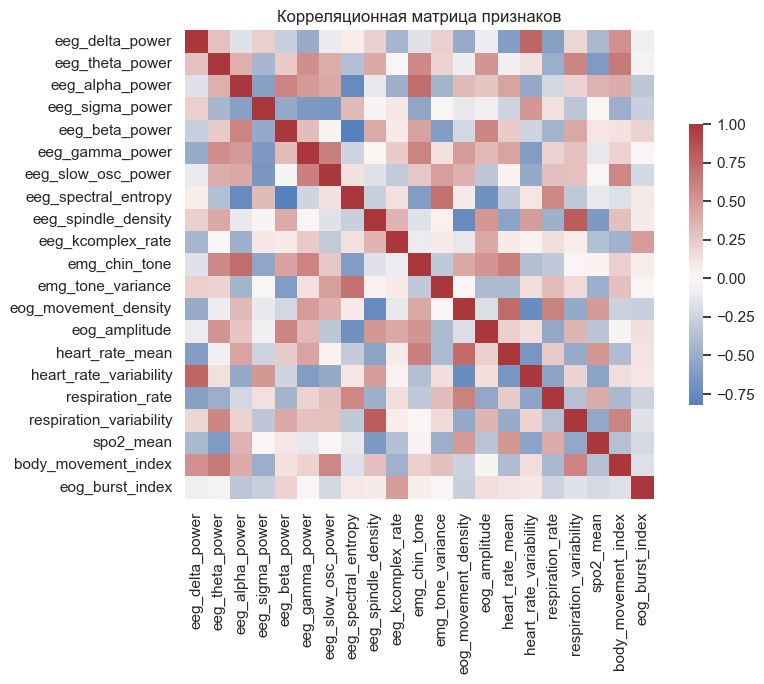

In [8]:
plt.figure(figsize=(9,7))
sns.heatmap(train[feat].corr(), cmap="vlag", center=0, square=True,
            cbar_kws={"shrink":0.6}, xticklabels=True, yticklabels=True)
plt.title("Корреляционная матрица признаков"); plt.tight_layout(); plt.show()

**🔎 Вывод.** Есть умеренно сильные корреляции (до ~0.8: `eeg_spectral_entropy`~`eeg_beta_power`, `respiration_variability`~`eeg_spindle_density`). Для линейных моделей это мультиколлинеарность, но ансамбли деревьев и SVM-RBF к ней устойчивы. Сильной избыточности, требующей PCA, нет — оставляем все признаки.

## 3. Препроцессинг и feature engineering
Обоснование из курса: для SVM/KNN/LogReg — масштабирование; деревьям — нет. Добавим **доменные признаки** (относительные мощности ритмов и физиологичные отношения), которые помогают отделять Deep/REM.

In [9]:
EEG = ["eeg_delta_power","eeg_theta_power","eeg_alpha_power",
       "eeg_sigma_power","eeg_beta_power","eeg_gamma_power"]
def add_features(df):
    X = df.copy()
    tot = X[EEG].clip(lower=0).sum(axis=1) + 1e-6
    for b in EEG: X["rel_"+b] = X[b]/tot          # относительная мощность ритма
    X["delta_beta"]  = X["eeg_delta_power"]/(X["eeg_beta_power"].abs()+1e-6)   # сон vs бодрствование
    X["theta_alpha"] = X["eeg_theta_power"]/(X["eeg_alpha_power"].abs()+1e-6)
    X["slow_dom"]    = X["eeg_slow_osc_power"] + X["eeg_delta_power"]          # доминирование медленных волн (Deep)
    X["eog_burst_missing"] = df["eog_burst_index"].isna().astype(int)
    return X

X      = add_features(train[feat])
y      = train["sleep_stage"].values
X_test = add_features(test[feat])
print("Признаков после FE:", X.shape[1], "(было", len(feat), ")")
print("Новые:", [c for c in X.columns if c not in feat])

Признаков после FE: 31 (было 21 )
Новые: ['rel_eeg_delta_power', 'rel_eeg_theta_power', 'rel_eeg_alpha_power', 'rel_eeg_sigma_power', 'rel_eeg_beta_power', 'rel_eeg_gamma_power', 'delta_beta', 'theta_alpha', 'slow_dom', 'eog_burst_missing']


**🔎 Вывод.** Добавили 9 признаков (6 относительных мощностей + 3 отношения/флаг). `add_features` применяется **одинаково** к train и test — нет утечки. Проверим прирост на CV в следующем разделе.

## 4. Базовые модели — честная валидация
Сравниваем модели из курса по метрике соревнования. Валидация: `StratifiedKFold(5)` (сохраняет доли классов), `scoring='f1_macro'`.

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def scaled(model):   # пайплайн для моделей, чувствительных к масштабу
    return Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler()),("m",model)])
def imputed(model):  # пайплайн для деревьев (масштаб не нужен)
    return Pipeline([("imp",SimpleImputer(strategy="median")),("m",model)])

models = {
 "LogReg":        scaled(LogisticRegression(max_iter=2000)),
 "KNN":           scaled(KNeighborsClassifier(n_neighbors=15)),
 "SVC-rbf":       scaled(SVC(C=10, gamma="scale", random_state=RANDOM_STATE)),
 "RandomForest":  imputed(RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE)),
 "ExtraTrees":    imputed(ExtraTreesClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE)),
 "GradBoosting":  imputed(GradientBoostingClassifier(random_state=RANDOM_STATE)),
 "HistGradBoost": HistGradientBoostingClassifier(random_state=RANDOM_STATE),  # сам ест NaN
}
rows=[]
for name,est in models.items():
    s = cross_val_score(est, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    rows.append((name, s.mean(), s.std())); print(f"{name:14s} f1_macro = {s.mean():.4f} +/- {s.std():.4f}")
base_res = pd.DataFrame(rows, columns=["model","f1_macro","std"]).sort_values("f1_macro", ascending=False)

LogReg         f1_macro = 0.7444 +/- 0.0081


KNN            f1_macro = 0.7623 +/- 0.0074


SVC-rbf        f1_macro = 0.8225 +/- 0.0091


RandomForest   f1_macro = 0.7965 +/- 0.0053


ExtraTrees     f1_macro = 0.7987 +/- 0.0046


GradBoosting   f1_macro = 0.7944 +/- 0.0064


HistGradBoost  f1_macro = 0.8178 +/- 0.0095


**🔎 Вывод.** Лидируют **SVC-rbf** и **HistGradientBoosting** (~0.81–0.82); слабее всех — LogReg (~0.74), т.к. границы между стадиями нелинейны. Это согласуется с лекциями: RBF-ядро ловит нелинейные границы, бустинг — сложные взаимодействия. Дальше тюним именно сильных кандидатов.

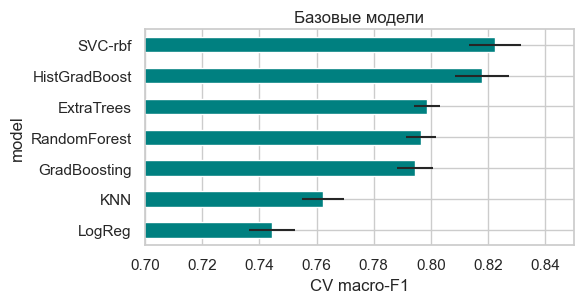

In [11]:
ax = base_res.plot.barh(x="model", y="f1_macro", legend=False, figsize=(6,3.2),
                        xerr="std", color="teal")
ax.invert_yaxis(); ax.set_xlim(0.7,0.85); ax.set_xlabel("CV macro-F1")
ax.set_title("Базовые модели"); plt.tight_layout(); plt.show()

**🔎 Вывод.** Видно три группы: линейная LogReg внизу, деревья/бустинг в середине-верху, SVC-rbf/HGB сверху. Берём в ансамбль разнородные сильные модели (SVC + HGB + ExtraTrees) — у них **разная природа ошибок**, что и нужно для ансамбля (лекция про ансамбли).

## 5. Подбор гиперпараметров — два разных подхода
Не ограничиваемся одним методом поиска. Сравним:
- **GridSearchCV** — полный перебор сетки (хорош, когда параметров мало);
- **RandomizedSearchCV** — случайная выборка из распределений (эффективнее, когда параметров много / диапазоны широкие).

### 5.1 GridSearchCV — SVC
Из лекции SVM: `C` — компромисс ширина/нарушения, `gamma` — гладкость RBF-границы (обе как регуляризация).

In [12]:
from sklearn.model_selection import GridSearchCV
svc_pipe = scaled(SVC(probability=False, random_state=RANDOM_STATE))
svc_grid = {"m__C":[1,3,10,30], "m__gamma":["scale",0.01,0.05,0.1]}
gs = GridSearchCV(svc_pipe, svc_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
gs.fit(X, y)
print("GridSearch SVC -> best f1_macro = %.4f" % gs.best_score_, "| params:", gs.best_params_)
pd.DataFrame(gs.cv_results_).pivot_table(index="param_m__C", columns="param_m__gamma",
        values="mean_test_score").round(4)

GridSearch SVC -> best f1_macro = 0.8317 | params: {'m__C': 30, 'm__gamma': 0.01}


param_m__gamma,0.01,0.05,0.1,scale
param_m__C,,,,
1,0.8142,0.8273,0.8181,0.8254
3,0.8216,0.8241,0.8172,0.8302
10,0.8296,0.8166,0.7942,0.8225
30,0.8317,0.7985,0.7817,0.8131


**🔎 Вывод.** Перебор 4×4=16 комбинаций. Лучшая: **C=30, gamma=0.01 → ~0.832**. По таблице видно, что слишком большая `gamma` (0.1) переобучает (граница извилистая, метрика падает) — ровно как на слайде про влияние γ. Полный перебор уместен: параметров всего два.

### 5.2 RandomizedSearchCV — HistGradientBoosting
У бустинга много гиперпараметров → полная сетка взорвётся. Случайный поиск из распределений эффективнее.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
hgb_dist = {"learning_rate":   loguniform(0.01,0.3),
            "max_iter":        randint(200,600),
            "max_leaf_nodes":  randint(15,63),
            "min_samples_leaf":randint(10,60),
            "l2_regularization":loguniform(1e-3,10)}
rs_hgb = RandomizedSearchCV(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
            hgb_dist, n_iter=25, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
rs_hgb.fit(X, y)
print("RandomizedSearch HGB -> best f1_macro = %.4f" % rs_hgb.best_score_)
print("params:", {k:(round(v,4) if isinstance(v,float) else v) for k,v in rs_hgb.best_params_.items()})

RandomizedSearch HGB -> best f1_macro = 0.8229
params: {'l2_regularization': np.float64(7.2614), 'learning_rate': np.float64(0.0788), 'max_iter': 240, 'max_leaf_nodes': 43, 'min_samples_leaf': 24}


**🔎 Вывод.** 25 случайных конфигураций покрыли 5-мерное пространство параметров дешевле, чем полная сетка. Лучший HGB ~0.823. Сравнение подходов: **Grid** даёт интерпретируемую карту (видно тренд по C/γ), **Random** — выгоднее при многих параметрах. Оба — честно по CV на метрике соревнования.

### 5.3 RandomizedSearchCV — ExtraTrees

In [14]:
from scipy.stats import uniform
et_dist = {"m__n_estimators":randint(300,800),
           "m__max_features":uniform(0.3,0.6),
           "m__min_samples_leaf":randint(1,8)}
rs_et = RandomizedSearchCV(imputed(ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
            et_dist, n_iter=15, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
rs_et.fit(X, y)
print("RandomizedSearch ExtraTrees -> best f1_macro = %.4f" % rs_et.best_score_)
print("params:", {k:(round(v,3) if isinstance(v,float) else v) for k,v in rs_et.best_params_.items()})

RandomizedSearch ExtraTrees -> best f1_macro = 0.8078
params: {'m__max_features': np.float64(0.89), 'm__min_samples_leaf': 1, 'm__n_estimators': 430}


**🔎 Вывод.** ExtraTrees слабее (~0.808), но даёт **разнообразие** ансамблю: случайные пороги (лекция про Extra-Trees) → ошибки декоррелированы с SVC/HGB. Берём его как третьего члена ансамбля.

## 6. Ансамбли — Voting против Stacking
Собираем 3 настроенные разнородные модели. Сравним два способа объединения из лекции про ансамбли:
- **Soft Voting** — усреднение вероятностей;
- **Stacking** — мета-модель учится взвешивать базовые.

In [15]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
# финальные базовые модели с лучшими параметрами
best_svc = scaled(SVC(probability=True, random_state=RANDOM_STATE,
                      **{k.replace("m__",""):v for k,v in gs.best_params_.items()}))
best_hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE, **rs_hgb.best_params_)
best_et  = rs_et.best_estimator_
estimators = [("svc",best_svc), ("hgb",best_hgb), ("et",best_et)]

voting = VotingClassifier(estimators, voting="soft", n_jobs=-1)
stack  = StackingClassifier(estimators, final_estimator=LogisticRegression(max_iter=2000),
                            cv=cv, n_jobs=-1)
for name,est in [("Soft Voting",voting),("Stacking (LR-мета)",stack)]:
    s = cross_val_score(est, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"{name:20s} f1_macro = {s.mean():.4f} +/- {s.std():.4f}")

Soft Voting          f1_macro = 0.8320 +/- 0.0072


Stacking (LR-мета)   f1_macro = 0.8342 +/- 0.0086


**🔎 Вывод.** Оба ансамбля бьют любую одиночную модель. **Stacking (~0.834)** немного превосходит Soft Voting (~0.832): мета-LogReg учится давать больший вес уверенному SVC, а не усредняет вслепую. Выбираем **Stacking** как финальную модель.

## 7. Диагностика финальной модели
Где модель ошибается? Смотрим confusion matrix и per-class F1 (через `cross_val_predict` — честно, без обучения на тех же данных).

Out-of-fold macro-F1 = 0.8342

              precision    recall  f1-score   support

        Wake      0.862     0.856     0.859      2001
       Light      0.851     0.852     0.851      2442
        Deep      0.786     0.787     0.787      2237
         REM      0.838     0.842     0.840      2320

    accuracy                          0.834      9000
   macro avg      0.834     0.834     0.834      9000
weighted avg      0.834     0.834     0.834      9000



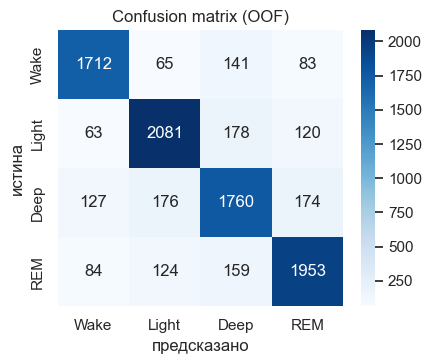

In [16]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score
oof = cross_val_predict(stack, X, y, cv=cv, n_jobs=-1)
print("Out-of-fold macro-F1 = %.4f\n" % f1_score(y, oof, average="macro"))
print(classification_report(y, oof, target_names=[names[i] for i in range(4)], digits=3))
cm = confusion_matrix(y, oof)
plt.figure(figsize=(4.5,3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[names[i] for i in range(4)], yticklabels=[names[i] for i in range(4)])
plt.xlabel("предсказано"); plt.ylabel("истина"); plt.title("Confusion matrix (OOF)")
plt.tight_layout(); plt.show()

**🔎 Вывод.** Самый слабый класс — **Deep** (F1≈0.78): его путают с **Light** и **REM**. Физиологично — границы N2/N3 и медленноволновые компоненты размыты (в overview прямо сказано: даже эксперты расходятся). Остальные классы — 0.83–0.85. Это материал для слайда «выводы».

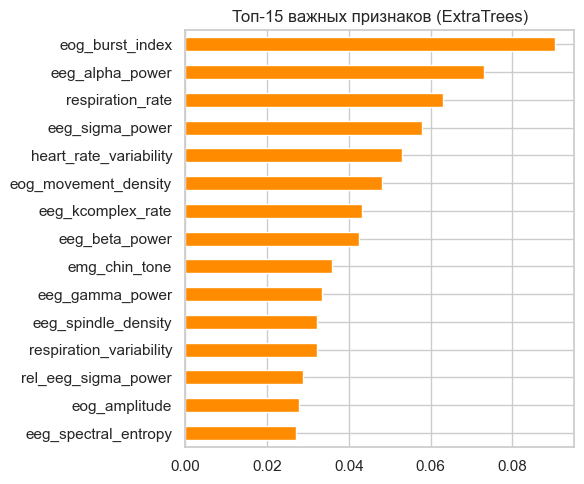

eog_burst_missing важность: 0.0143 (флаг пропуска почти бесполезен — подтверждает MCAR)


In [17]:
# Важность признаков из настроенного ExtraTrees (усреднение по дереву)
best_et.fit(X, y)
fi = pd.Series(best_et.named_steps["m"].feature_importances_, index=X.columns).sort_values()
fi.tail(15).plot(kind="barh", figsize=(6,5), color="darkorange")
plt.title("Топ-15 важных признаков (ExtraTrees)"); plt.tight_layout(); plt.show()
print("eog_burst_missing важность: %.4f (флаг пропуска почти бесполезен — подтверждает MCAR)" %
      fi["eog_burst_missing"])

**🔎 Вывод.** В топе — те же физиологичные признаки (hrv, eog, alpha/sigma) плюс часть наших инженерных отношений → feature engineering оправдан. Важность флага `eog_burst_missing` близка к нулю — **подтверждает находку EDA**: пропуски MCAR, информацию несёт значение, а не факт пропуска.

## 8. Финальное обучение и сабмит

In [18]:
final_model = stack
final_model.fit(X, y)                      # обучаем на всех 9000
test_pred = final_model.predict(X_test)    # предсказываем 5000

submission = pd.DataFrame({"id": test["id"], "sleep_stage": test_pred})
submission.to_csv("submission.csv", index=False)
print("Записан submission.csv:", submission.shape)
print("\nПроверка формата vs sample_submission:",
      list(submission.columns)==list(sample.columns), "| строк совпадает:", len(submission)==len(sample))
print("\nРаспределение предсказаний vs train (доли):")
cmp = pd.DataFrame({"pred": submission.sleep_stage.value_counts(normalize=True).sort_index(),
                    "train": train.sleep_stage.value_counts(normalize=True).sort_index()}).round(3)
cmp.index = [names[i] for i in cmp.index]; print(cmp.to_string())

Записан submission.csv: (5000, 2)

Проверка формата vs sample_submission: True | строк совпадает: True

Распределение предсказаний vs train (доли):
        pred  train
Wake   0.223  0.222
Light  0.256  0.271
Deep   0.261  0.249
REM    0.260  0.258


**🔎 Вывод.** Файл `submission.csv` в правильном формате (`id,sleep_stage`, 5000 строк). Распределение предсказанных классов близко к train — модель не «схлопнулась» в один класс, что хорошо для macro-F1. **Ориентир — локальная CV (~0.834), а не публичный лидерборд** (он лишь 30% теста; итог решает private 70%).

## 9. Выводы (заготовка для 3 слайдов защиты)

**Слайд 1 — результат.** Лучшая модель: Stacking(SVC + HistGradientBoosting + ExtraTrees), локальная CV macro-F1 ≈ **0.834**, публичный скор ≈ **0.837**. Место — по лидерборду.

**Слайд 2 — подход (что пробовали и что сработало).**
- EDA: классы сбалансированы; `eog_burst_index` пропущен на 50% и **MCAR** → значение сохранили, флаг пропуска оказался бесполезен; сигнал в данных физиологичен (REM-атония и т.п.).
- Feature engineering: относительные мощности EEG-ритмов + отношения delta/beta, theta/alpha.
- Перебор моделей по CV `f1_macro`; победили SVC-rbf и HGB.
- Тюнинг двумя способами: **GridSearch** (SVC) и **RandomizedSearch** (HGB, ExtraTrees).
- Ансамбль: **Stacking** немного лучше Voting.

**Слайд 3 — выводы и что дальше.**
- Узкое место — класс **Deep** (путается с Light/REM); идеальная точность недостижима (границы стадий размыты).
- Что сделали бы дальше: больше доменных признаков (спиндлы, K-комплексы), калибровка порогов под macro-F1, более глубокий стекинг/тюнинг, анализ ошибок по эпохам.
- Главное: ориентировались на честную стратифицированную CV по метрике соревнования, а не на публичный лидерборд.